⚠️ Không thể kết nối MySQL ((pymysql.err.OperationalError) (2003, "Can't connect to MySQL server on 'None' ([Errno 11001] getaddrinfo failed)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)). Tự động chuyển sang đọc file CSV dự phòng...
✅ Đã load dữ liệu thành công từ file CSV cha.

🚀 Đang huấn luyện XGBoost Regression...
🚀  Đang huấn luyện XGBoost Classification...

💎 Đang tối ưu hóa phân cụm (Clustering)...


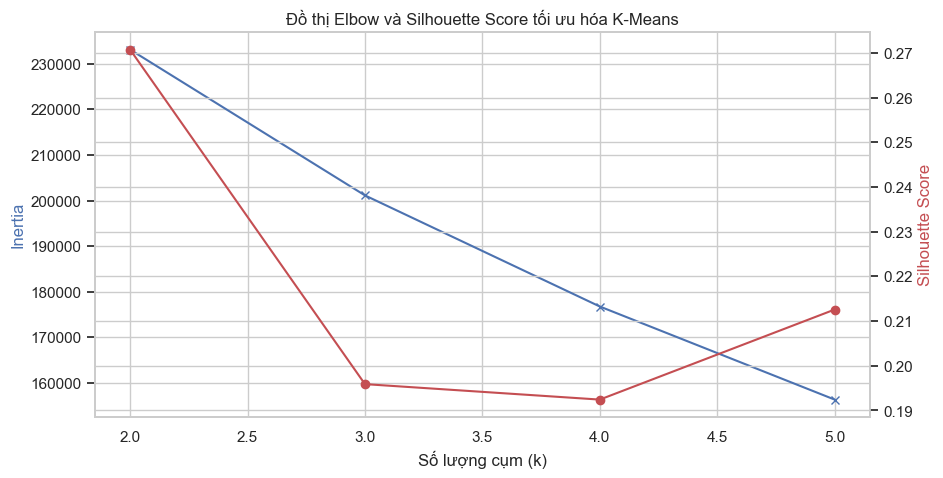


📋 CLUSTER PROFILE REPORT (Giá trị trung bình gốc của từng cụm):
                      aqi       pm25        pm10          co        no2  \
cluster_label                                                             
0              112.933150  40.057864   51.799637  167.048668  14.074708   
1               95.525145  32.563011   44.566275  414.999586  24.690874   
2              195.379621  98.754436  138.012560  367.051765  46.708971   

                       o3        so2  temperature  relative_humidity  \
cluster_label                                                          
0              112.449790  79.336221    29.180069          62.366918   
1               39.649929  46.004707    25.098856          84.872947   
2               40.849467  82.464669    20.082639          77.021459   

                  pressure  
cluster_label               
0              1007.595196  
1              1008.357784  
2              1016.359131  


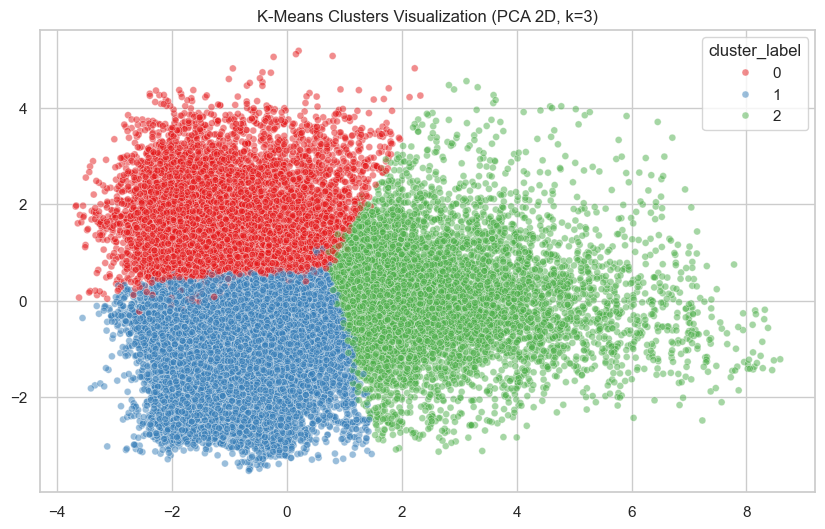


🧬 Đang tính toán SHAP values dựa trên TreeExplainer...
📊 Hiển thị SHAP Summary Plot cho Mô hình Hồi quy...


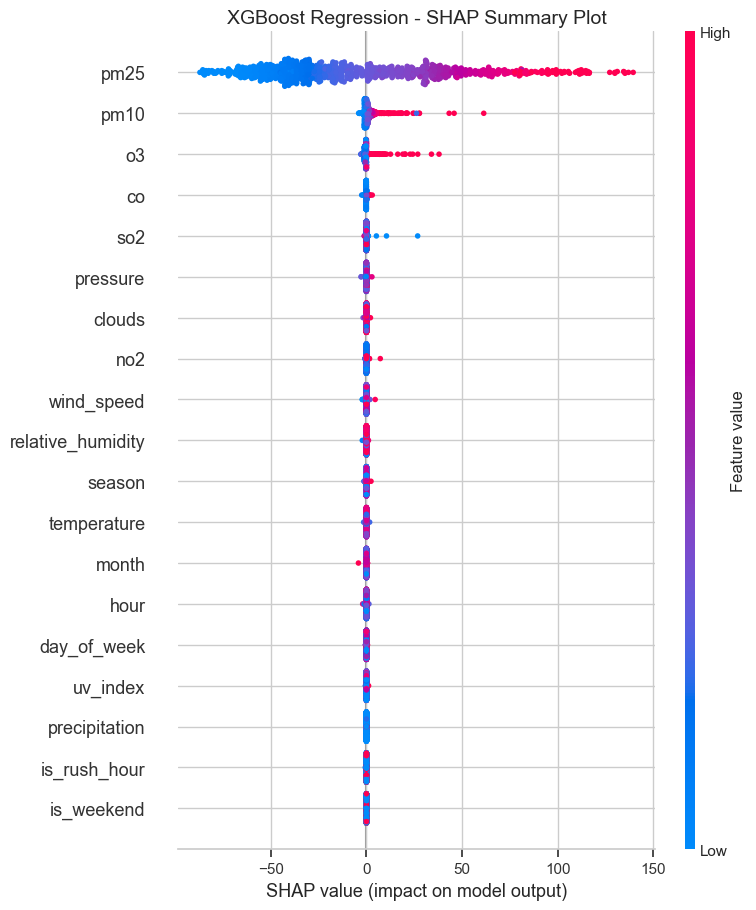

📊 Hiển thị SHAP Summary Plot cho Mô hình Phân loại ...


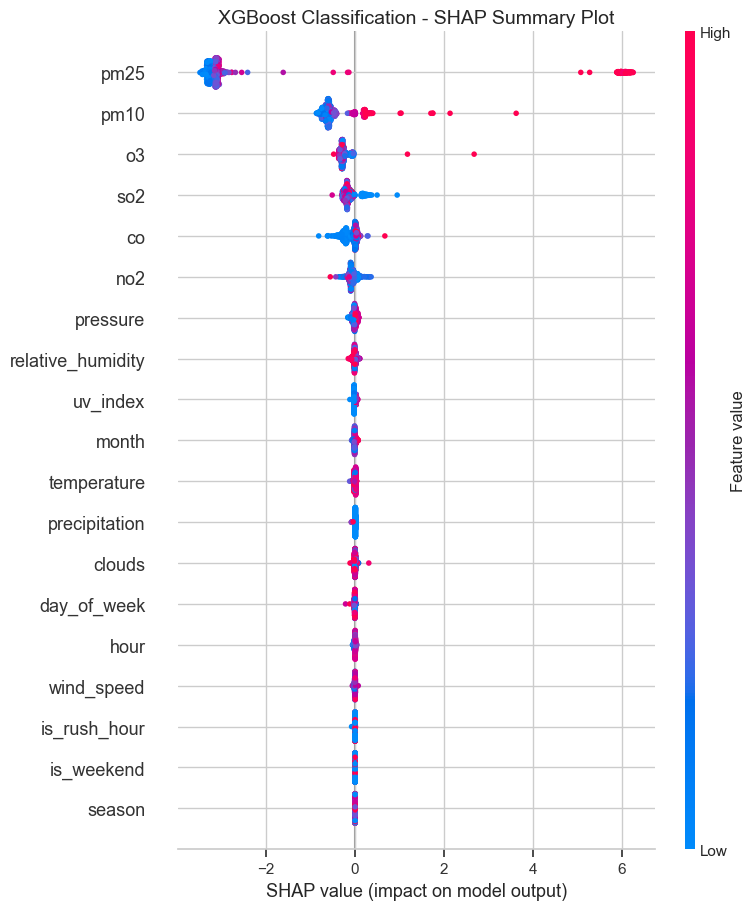


💡 Trực quan Waterfall Plot cho thời điểm đỉnh điểm ô nhiễm: 2025-04-02 22:00:00


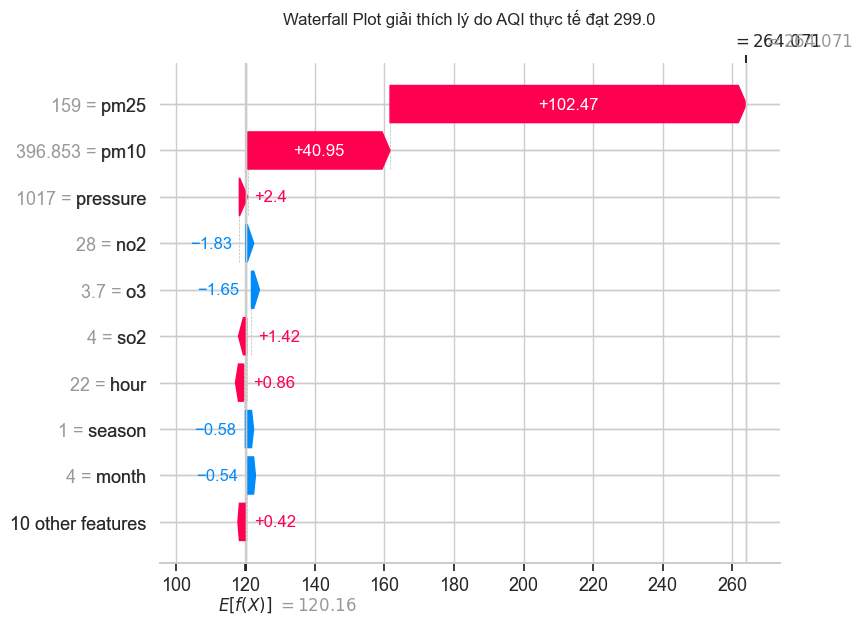


📈 Hiển thị Dependency Plot cho biến PM2.5 tương tác với Độ ẩm (Humidity)...


<Figure size 1000x600 with 0 Axes>

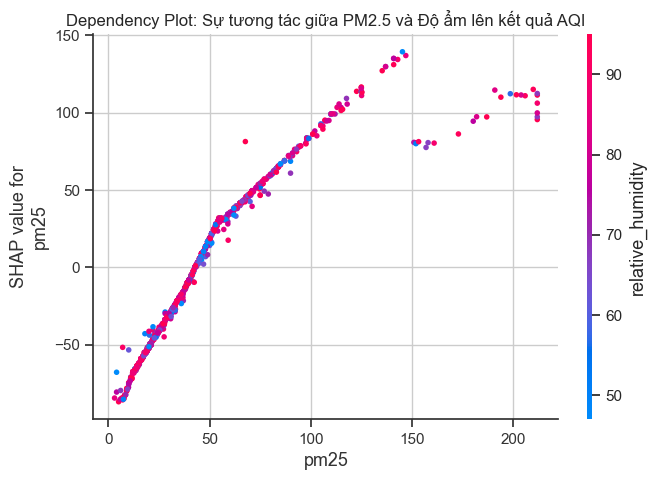


════════════════════════════════════════════════════════════
🏆 KẾT LUẬN: Feature drive chỉ số AQI nhiều nhất toàn cục là: 'PM25'
📂 Các mô hình tốt nhất đã được cập nhật sang XGBoost và lưu tại: 'library_framework/'
✨ Tiến trình phân tích báo cáo kỹ thuật hoàn tất hoàn hảo.
════════════════════════════════════════════════════════════


In [11]:
import pandas as pd
import numpy as np
import warnings
import shap
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sqlalchemy import create_engine  # Khôi phục thư viện kết nối MySQL
from dotenv import load_dotenv        # Khôi phục thư viện đọc file cấu hình môi trường
import xgboost as xgb 

# Tải cấu hình bảo mật từ file .env
load_dotenv(dotenv_path=os.path.join(os.path.dirname(__file__), '../.env') if '__file__' in locals() else '.env')

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# ══════════════════════════════════════════════════════
# 1. ĐỌC DỮ LIỆU TỪ MYSQL (CÓ ĐỌC FILE CSV DỰ PHÒNG)
# ══════════════════════════════════════════════════════
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
DB_PORT = os.getenv("DB_PORT")

if DB_PORT is None or DB_PORT == "None" or DB_PORT == "":
    DB_PORT = 3307
else:
    DB_PORT = int(DB_PORT)

df = None

try:
    # Khởi tạo engine kết nối an toàn đến MySQL
    engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
    
    # Câu lệnh truy vấn tối ưu liên kết 3 bảng dựa trên local_time
    query = """
        SELECT 
            tg.local_time, tg.year, tg.month, tg.hour, tg.day_of_week, tg.is_weekend, tg.is_rush_hour, tg.season,
            tt.clouds, tt.precipitation, tt.pressure, tt.relative_humidity, tt.temperature, tt.uv_index, tt.wind_speed,
            ck.co, ck.no2, ck.o3, ck.pm10, ck.pm25, ck.so2, ck.aqi
        FROM thoi_gian tg
        INNER JOIN thoi_tiet tt ON tg.local_time = tt.local_time
        INNER JOIN chat_luong_khong_khi ck ON tg.local_time = ck.local_time
    """
    df = pd.read_sql(query, con=engine)
    print(f"✅ Kết nối MySQL thành công. Đã lấy {len(df)} dòng dữ liệu từ database.")
    engine.dispose()

except Exception as e:
    print(f"⚠️ Không thể kết nối MySQL ({e}). Tự động chuyển sang đọc file CSV dự phòng...")
    try:
        df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
        print("✅ Đã load dữ liệu thành công từ file CSV cha.")
    except Exception:
        df = pd.read_csv('./hanoi_aqi_cleaned.csv')
        print("✅ Đã load dữ liệu thành công từ file CSV cục bộ.")

# ══════════════════════════════════════════════════════
# TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
# ══════════════════════════════════════════════════════
SEASON_MAP = {0: 'Đông', 1: 'Xuân', 2: 'Hè', 3: 'Thu'}
df.columns = df.columns.str.strip().str.lower()
df['local_time'] = pd.to_datetime(df['local_time'], errors='coerce')
df['season_name'] = df['season'].map(SEASON_MAP)

# Định nghĩa các tập biến đặc trưng
FEATURES = [
    'co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 'precipitation', 
    'pressure', 'relative_humidity', 'temperature', 'uv_index', 'wind_speed',
    'month', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'season'
]
TARGET_REG = 'aqi'
TARGET_CLS = 'aqi_label'  # Nhãn phân loại ô nhiễm cho Minh Trường

# Tạo nhãn phân loại giả định nếu dữ liệu gốc chưa có sẵn
if TARGET_CLS not in df.columns:
    df[TARGET_CLS] = pd.cut(df[TARGET_REG], bins=[-1, 100, 200, 999], labels=[0, 1, 2]).astype(int)

# Tách dữ liệu Train (<2025) và Test (2025)
train = df[df['year'] < 2025].copy()
test = df[df['year'] == 2025].copy()

X_train = train[FEATURES].fillna(train[FEATURES].median()).astype(float)
y_train_reg = train[TARGET_REG].fillna(train[TARGET_REG].median())
y_train_cls = train[TARGET_CLS].fillna(train[TARGET_CLS].mode()[0])

X_test = test[FEATURES].fillna(train[FEATURES].median()).astype(float)

os.makedirs('library_framework', exist_ok=True)

# ══════════════════════════════════════════════════════
# 2. HUẤN LUYỆN XGBOOST REGRESSION 
# ══════════════════════════════════════════════════════
print("\n🚀 Đang huấn luyện XGBoost Regression...")
xgb_reg = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_reg.fit(X_train, y_train_reg)
joblib.dump(xgb_reg, 'library_framework/best_model_regression.pkl')

# ══════════════════════════════════════════════════════
# 3. HUẤN LUYỆN XGBOOST CLASSIFICATION 
# ══════════════════════════════════════════════════════
print("🚀  Đang huấn luyện XGBoost Classification...")
xgb_cls = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_cls.fit(X_train, y_train_cls)
joblib.dump(xgb_cls, 'library_framework/best_model_classification.pkl')

# ══════════════════════════════════════════════════════
# 4. GOM CỤM K-MEANS NÂNG CAO & REPORT
# ══════════════════════════════════════════════════════
print("\n💎 Đang tối ưu hóa phân cụm (Clustering)...")
cluster_features = ['aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2', 'temperature', 'relative_humidity', 'pressure']
X_cl = df[cluster_features].copy().fillna(df[cluster_features].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cl)

# 4.1 Elbow Plot & Silhouette Score (Tính toán trên TOÀN BỘ dữ liệu X_scaled)
distortions = []
sil_scores = []
K_range = range(2, 6)

for k in K_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km_test.fit_predict(X_scaled)
    distortions.append(km_test.inertia_)
    
    # ĐÃ BỎ lấy mẫu ngẫu nhiên sample_idx -> Tính trực tiếp trên toàn bộ dữ liệu X_scaled
    score = silhouette_score(X_scaled, km_labels, random_state=42)
    sil_scores.append(score)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, distortions, 'bx-', label='Inertia (Elbow)')
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.set_title('Đồ thị Elbow và Silhouette Score tối ưu hóa K-Means')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.show()

# 4.2 Huấn luyện K-Means với k=3 tối ưu
k_opt = 3
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['cluster_label'] = km_final.fit_predict(X_scaled)

# 4.3 Cluster Profile Report
print("\n📋 CLUSTER PROFILE REPORT (Giá trị trung bình gốc của từng cụm):")
profile = df.groupby('cluster_label')[cluster_features].mean()
print(profile)

# 4.4 Visualize Cluster trên PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_label'], palette='Set1', s=25, alpha=0.5)
plt.title(f'K-Means Clusters Visualization (PCA 2D, k={k_opt})')
plt.show()

# ══════════════════════════════════════════════════════
# 5. GIẢI THÍCH MÔ HÌNH VỚI SHAP TREEEXPLAINER
# ══════════════════════════════════════════════════════
print("\n🧬 Đang tính toán SHAP values dựa trên TreeExplainer...")
X_shap = X_train.sample(n=min(1000, len(X_train)), random_state=42)

explainer_reg = shap.TreeExplainer(xgb_reg)
shap_values_reg = explainer_reg(X_shap)

explainer_cls = shap.TreeExplainer(xgb_cls)
shap_values_cls = explainer_cls(X_shap)

# 5.1 SHAP Summary Plot (Toàn cục)
print("📊 Hiển thị SHAP Summary Plot cho Mô hình Hồi quy...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_reg, X_shap, show=False)
plt.title("XGBoost Regression - SHAP Summary Plot", fontsize=14)
plt.show()

print("📊 Hiển thị SHAP Summary Plot cho Mô hình Phân loại ...")
plt.figure(figsize=(10, 6))
if hasattr(shap_values_cls, "values") and len(shap_values_cls.values.shape) == 3:
    shap.summary_plot(shap_values_cls.values[:, :, -1], X_shap, show=False)
else:
    shap.summary_plot(shap_values_cls, X_shap, show=False)
plt.title("XGBoost Classification - SHAP Summary Plot", fontsize=14)
plt.show()

# 5.2 Waterfall Plot: Giải thích chi tiết 1 dự đoán cụ thể khi AQI chạm ngưỡng ~300
if len(test) > 0:
    example_idx = (test[TARGET_REG] - 300).abs().idxmin()
    example_x = test.loc[[example_idx]][FEATURES].astype(float)
    
    shap_single_reg = explainer_reg(example_x)
    
    print(f"\n💡 Trực quan Waterfall Plot cho thời điểm đỉnh điểm ô nhiễm: {test.loc[example_idx, 'local_time']}")
    plt.figure(figsize=(11, 6))
    shap.plots.waterfall(shap_single_reg[0], show=False)
    plt.title(f"Waterfall Plot giải thích lý do AQI thực tế đạt {test.loc[example_idx, TARGET_REG]:.1f}", fontsize=12)
    plt.show()

# 5.3 Dependency Plot: PM2.5 ảnh hưởng đến AQI thế nào khi các feature khác thay đổi
print("\n📈 Hiển thị Dependency Plot cho biến PM2.5 tương tác với Độ ẩm (Humidity)...")
plt.figure(figsize=(10, 6))
shap.dependence_plot('pm25', shap_values_reg.values, X_shap, interaction_index='relative_humidity', show=False)
plt.title('Dependency Plot: Sự tương tác giữa PM2.5 và Độ ẩm lên kết quả AQI', fontsize=12)
plt.show()

# ══════════════════════════════════════════════════════
# 6. KẾT LUẬN CUỐI CÙNG
# ══════════════════════════════════════════════════════
if hasattr(shap_values_reg, "values"):
    vals = shap_values_reg.values
else:
    vals = shap_values_reg
feat_imp = pd.DataFrame({'Feature': FEATURES, 'Importance': np.abs(vals).mean(axis=0)})
top_f = feat_imp.sort_values('Importance', ascending=False).iloc[0]['Feature']

print("\n" + "═"*60)
print(f"🏆 KẾT LUẬN: Feature drive chỉ số AQI nhiều nhất toàn cục là: '{top_f.upper()}'")
print(f"📂 Các mô hình tốt nhất đã được cập nhật sang XGBoost và lưu tại: 'library_framework/'")
print("✨ Tiến trình phân tích báo cáo kỹ thuật hoàn tất hoàn hảo.")
print("═"*60)